# BusterNet Validation Diagnostics

Validation-split notebook for Einar's DINO-BusterNet checkpoints. It rebuilds the same validation split, caches prediction probabilities once, reports forged/authentic diagnostics, and plots examples. Do not use the reserved local holdout split here.

In [29]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "einar_busternet").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(PROJECT_ROOT)


/home/einar/projects/INF367A-26V-Recod.ai-LUC-Forgery-Kaggle


## Configuration

`ALLOW_TORCH_HUB` must be `True` before the model is rebuilt. This is intentional because model construction uses official DINO through `torch.hub` and may initialize cached DINO assets.

In [30]:
CHECKPOINT_CHOICE = "best"  # "best", "last", or "custom"
CUSTOM_CHECKPOINT_PATH = None
CHECKPOINT_PATHS = {
    "best": Path("einar_busternet/artifacts/checkpoints/best.pt"),
    "last": Path("einar_busternet/artifacts/checkpoints/last.pt"),
}
CHECKPOINT_PATH = Path(CUSTOM_CHECKPOINT_PATH) if CHECKPOINT_CHOICE == "custom" else CHECKPOINT_PATHS[CHECKPOINT_CHOICE]

DEVICE = "auto"
ALLOW_TORCH_HUB = True
VAL_SUBSET = None
BATCH_SIZE = None
VALIDATION_TRANSFER_MODE = None  # None uses checkpoint config, usually "accumulate_gpu"
THRESHOLD_FOR_TABLES = None      # None uses config.pred_threshold

# Keep this notebook light. Set lists below to try a few alternatives.
MAX_SWEEP_SETTINGS = 5
PRED_THRESHOLDS = [0.1, 0.2, 0.25, 0.3, 0.4]
MIN_COMPONENT_AREAS = None
CONFIDENT_THRESHOLDS = None
SMOOTH_OPTIONS = None
OPENING_OPTIONS = None
CLOSING_OPTIONS = None
FILL_HOLES_OPTIONS = None
KEEP_CONFIDENT_SEEDED_OPTIONS = None


In [31]:
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from dataset_utils import list_labeled_samples
from datasets.splits import make_grouped_stratified_splits
from engine.checkpointing import load_checkpoint
from engine.validation_inference import collect_validation_predictions, score_validation_predictions, _post_process_probability
from engine.validation_records import load_resized_instance_masks
from evaluate_validation_postprocess import iter_postprocess_settings
from einar_busternet.evaluate import (
    _build_val_loader,
    _resolve_device,
    config_from_checkpoint,
    validate_model_loading_allowed,
)
from einar_busternet.model import BusterNetUnionWrapper
from einar_busternet.train import _build_sliding_window_fn, build_model
from inference.postprocess import post_process_prediction
from util.pixelmapUtil import PixelMapUtil
from visualization import ForgeryDataPlotter


## Load Checkpoint And Validation Split

In [32]:
validate_model_loading_allowed(ALLOW_TORCH_HUB)
if CHECKPOINT_CHOICE not in {"best", "last", "custom"}:
    raise ValueError(f"CHECKPOINT_CHOICE must be 'best', 'last', or 'custom', got {CHECKPOINT_CHOICE!r}")
if CHECKPOINT_CHOICE == "custom" and CUSTOM_CHECKPOINT_PATH is None:
    raise ValueError("CUSTOM_CHECKPOINT_PATH must be set when CHECKPOINT_CHOICE='custom'")

device = _resolve_device(DEVICE)
checkpoint = load_checkpoint(CHECKPOINT_PATH, map_location=device, trusted=True)
config = config_from_checkpoint(checkpoint)
if VAL_SUBSET is not None:
    config = type(config)(**{**config.__dict__, "val_subset": VAL_SUBSET})
if BATCH_SIZE is not None:
    config = type(config)(**{**config.__dict__, "batch_size": BATCH_SIZE})
if VALIDATION_TRANSFER_MODE is not None:
    config = type(config)(**{**config.__dict__, "validation_transfer_mode": VALIDATION_TRANSFER_MODE})

all_samples = list_labeled_samples(Path(config.data_root))
splits = make_grouped_stratified_splits(
    all_samples,
    seed=config.seed,
    train_ratio=config.train_ratio,
    val_ratio=config.val_ratio,
    test_ratio=config.test_ratio,
)
val_samples = splits["val"]
if config.val_subset is not None:
    val_samples = val_samples[: config.val_subset]

print(f"device={device}")
print(f"checkpoint_choice={CHECKPOINT_CHOICE}")
print(f"checkpoint={CHECKPOINT_PATH}")
print(f"checkpoint_epoch={checkpoint.get('epoch')}")
print(f"stored_kaggle_score={checkpoint.get('kaggle_score')}")
print(f"validation samples={len(val_samples)}")
print(f"batch_size={config.val_batch_size or config.batch_size}, transfer={config.validation_transfer_mode}")


device=cuda
checkpoint_choice=best
checkpoint=einar_busternet/artifacts/checkpoints/best.pt
checkpoint_epoch=7
stored_kaggle_score=0.5353868219691832
validation samples=514
batch_size=32, transfer=accumulate_gpu


## Cache Validation Predictions

This is the expensive cell. After it runs, the rest of the notebook reuses cached probability maps.

In [33]:
model = build_model(config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
wrapped_model = BusterNetUnionWrapper(model, eps=config.union_wrapper_eps)

val_loader = _build_val_loader(config, val_samples, device)
predictions = collect_validation_predictions(
    model=wrapped_model,
    val_loader=val_loader,
    val_samples=val_samples,
    device=device,
    inference_mode=config.validation_inference_mode,
    sliding_window_fn=_build_sliding_window_fn(config),
    probability_dtype=config.validation_probability_dtype,
    collect_masks=config.compute_pixel_f1,
    transfer_mode=config.validation_transfer_mode,
)
len(predictions)


Using cache found in /home/einar/.cache/torch/hub/facebookresearch_dinov2_main


514

## Overall Score

In [34]:
pixel_util = PixelMapUtil()
score_result = score_validation_predictions(
    predictions=predictions,
    pixel_util=pixel_util,
    pred_threshold=config.pred_threshold,
    harden_temperature=config.harden_temperature,
    hard_clip_low=config.hard_clip_low,
    hard_clip_high=config.hard_clip_high,
    min_component_area=config.min_component_area,
    compute_pixel_f1=config.compute_pixel_f1,
    verify_score_equivalence=config.verify_score_equivalence,
    confident_threshold=config.post_process_confident_threshold,
    smooth_probabilities=config.post_process_smooth_probabilities,
    fill_holes=config.post_process_fill_holes,
    apply_opening=config.post_process_apply_opening,
    apply_closing=config.post_process_apply_closing,
    keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
)
score_result


{'kaggle_score': 0.5353868219691832,
 'pixel_f1': None,
 'num_samples': 514,
 'num_forged': 276,
 'num_authentic': 238,
 'postprocess_seconds': 5.774233171000105,
 'scoring_seconds': 0.0826865959998031}

## Tiny Post-Processing Sweep

This reuses cached probabilities and tries at most `MAX_SWEEP_SETTINGS` settings. Keep it small for quick diagnosis; use the baseline sweep notebook if you want a larger post-processing search.

In [35]:
sweep_args = SimpleNamespace(
    pred_thresholds=PRED_THRESHOLDS or [config.pred_threshold],
    min_component_areas=MIN_COMPONENT_AREAS or [config.min_component_area],
    confident_thresholds=CONFIDENT_THRESHOLDS or [config.post_process_confident_threshold],
    smooth_options=SMOOTH_OPTIONS or [config.post_process_smooth_probabilities],
    opening_options=OPENING_OPTIONS or [config.post_process_apply_opening],
    closing_options=CLOSING_OPTIONS or [config.post_process_apply_closing],
    fill_holes_options=FILL_HOLES_OPTIONS or [config.post_process_fill_holes],
    keep_confident_seeded_options=KEEP_CONFIDENT_SEEDED_OPTIONS or [config.post_process_keep_confident_seeded_components],
    max_settings=MAX_SWEEP_SETTINGS,
)

sweep_rows = []
for rank, setting in enumerate(iter_postprocess_settings(config, sweep_args), start=1):
    result = score_validation_predictions(
        predictions=predictions,
        pixel_util=pixel_util,
        pred_threshold=setting["pred_threshold"],
        harden_temperature=setting["harden_temperature"],
        hard_clip_low=setting["hard_clip_low"],
        hard_clip_high=setting["hard_clip_high"],
        min_component_area=setting["min_component_area"],
        compute_pixel_f1=setting["compute_pixel_f1"],
        verify_score_equivalence=setting["verify_score_equivalence"],
        confident_threshold=setting["confident_threshold"],
        smooth_probabilities=setting["smooth_probabilities"],
        fill_holes=setting["fill_holes"],
        apply_opening=setting["apply_opening"],
        apply_closing=setting["apply_closing"],
        keep_confident_seeded_components=setting["keep_confident_seeded_components"],
    )
    sweep_rows.append({"rank": rank, **setting, **result})

sweep_df = pd.DataFrame(sweep_rows).sort_values("kaggle_score", ascending=False)
sweep_df


,rank,pred_threshold,min_component_area,confident_threshold,smooth_probabilities,apply_opening,apply_closing,fill_holes,keep_confident_seeded_components,harden_temperature,...,hard_clip_high,compute_pixel_f1,verify_score_equivalence,kaggle_score,pixel_f1,num_samples,num_forged,num_authentic,postprocess_seconds,scoring_seconds
4,5,0.40,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.532550,None,514,276,238,5.669229,0.087764
1,2,0.20,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.532210,None,514,276,238,5.682507,0.083345
3,4,0.30,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.531764,None,514,276,238,5.682792,0.080162
2,3,0.25,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.531674,None,514,276,238,5.684198,0.079550
0,1,0.10,50,0.9,True,True,True,True,False,0.7,...,0.9,False,False,0.530500,None,514,276,238,5.677139,0.084513


## Per-Sample Diagnostics

Authentic rows expose false positives. Forged rows expose empty predictions, missed GT area, predicted area ratio, and pixel IoU/F1 for quick debugging.

In [36]:
def gt_union_for_prediction(prediction):
    shape = prediction.probability.shape
    instances = load_resized_instance_masks(prediction.sample, shape)
    if not instances:
        return np.zeros(shape, dtype=np.uint8)
    gt = np.zeros(shape, dtype=np.uint8)
    for instance in instances:
        gt = np.maximum(gt, (instance > 0).astype(np.uint8))
    return gt


def pred_mask_for_prediction(prediction, threshold=None):
    threshold = config.pred_threshold if threshold is None else threshold
    return _post_process_probability(
        probability=prediction.probability,
        pixel_util=pixel_util,
        pred_threshold=threshold,
        harden_temperature=config.harden_temperature,
        hard_clip_low=config.hard_clip_low,
        hard_clip_high=config.hard_clip_high,
        min_component_area=config.min_component_area,
        confident_threshold=config.post_process_confident_threshold,
        smooth_probabilities=config.post_process_smooth_probabilities,
        fill_holes=config.post_process_fill_holes,
        apply_opening=config.post_process_apply_opening,
        apply_closing=config.post_process_apply_closing,
        keep_confident_seeded_components=config.post_process_keep_confident_seeded_components,
    )


def pixel_stats(pred_bin, gt_bin):
    pred = pred_bin > 0
    gt = gt_bin > 0
    tp = int((pred & gt).sum())
    fp = int((pred & ~gt).sum())
    fn = int((~pred & gt).sum())
    union = tp + fp + fn
    precision = tp / (tp + fp) if tp + fp else 1.0 if gt.sum() == 0 else 0.0
    recall = tp / (tp + fn) if tp + fn else 1.0 if pred.sum() == 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if precision + recall else 0.0
    iou = tp / union if union else 1.0
    return tp, fp, fn, precision, recall, f1, iou


def gt_size_bucket(gt_pixels):
    if gt_pixels == 0:
        return "authentic"
    if gt_pixels < 1_000:
        return "tiny"
    if gt_pixels < 5_000:
        return "small"
    if gt_pixels < 20_000:
        return "medium"
    return "large"

rows = []
threshold = config.pred_threshold if THRESHOLD_FOR_TABLES is None else THRESHOLD_FOR_TABLES
for idx, prediction in enumerate(predictions):
    pred_bin = pred_mask_for_prediction(prediction, threshold=threshold)
    gt_bin = gt_union_for_prediction(prediction)
    probability = prediction.probability.astype(np.float32, copy=False)
    tp, fp, fn, precision, recall, f1, iou = pixel_stats(pred_bin, gt_bin)
    gt_pixels = int(gt_bin.sum())
    pred_pixels = int(pred_bin.sum())
    rows.append({
        "idx": idx,
        "sample_id": prediction.sample.sample_id,
        "case_id": prediction.sample.case_id,
        "label": prediction.sample.label,
        "gt_pixels": gt_pixels,
        "pred_pixels": pred_pixels,
        "pred_to_gt_ratio": pred_pixels / gt_pixels if gt_pixels else np.nan,
        "gt_size_bucket": gt_size_bucket(gt_pixels),
        "fp_pixels": fp,
        "fn_pixels": fn,
        "precision": precision,
        "recall": recall,
        "pixel_f1": f1,
        "pixel_iou": iou,
        "max_prob": float(np.max(probability)),
        "mean_prob": float(np.mean(probability)),
        "p99_prob": float(np.quantile(probability, 0.99)),
        "pred_empty": int(pred_pixels == 0),
        "gt_empty": int(gt_bin.sum() == 0),
    })

diagnostic_df = pd.DataFrame(rows)
diagnostic_df.head()


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
0,0,authentic:10030,10030,authentic,0,0,NaN,authentic,0,0,1.000000,1.000000,1.000000,1.000000,0.005001,1.309922e-05,0.000159,1,1
1,1,forged:10030,10030,forged,13868,9642,0.695270,medium,2417,6643,0.749326,0.520984,0.614632,0.443660,1.000000,4.927459e-02,1.000000,0,0
2,2,authentic:10277,10277,authentic,0,0,NaN,authentic,0,0,1.000000,1.000000,1.000000,1.000000,0.000008,3.964717e-07,0.000003,1,1
3,3,forged:10277,10277,forged,19782,4689,0.237034,medium,167,15260,0.964385,0.228592,0.369580,0.226678,1.000000,2.371486e-02,0.999023,0,0
4,4,authentic:10730,10730,authentic,0,0,NaN,authentic,0,0,1.000000,1.000000,1.000000,1.000000,0.000012,2.510538e-07,0.000002,1,1


In [37]:
summary = diagnostic_df.groupby("label").agg(
    samples=("sample_id", "count"),
    mean_pred_pixels=("pred_pixels", "mean"),
    median_pred_pixels=("pred_pixels", "median"),
    total_fp_pixels=("fp_pixels", "sum"),
    empty_prediction_rate=("pred_empty", "mean"),
    nonempty_prediction_rate=("pred_empty", lambda s: 1.0 - s.mean()),
    mean_precision=("precision", "mean"),
    mean_recall=("recall", "mean"),
    mean_pixel_f1=("pixel_f1", "mean"),
    mean_pixel_iou=("pixel_iou", "mean"),
    mean_max_prob=("max_prob", "mean"),
    mean_p99_prob=("p99_prob", "mean"),
).reset_index()

forged_nonempty = diagnostic_df.query("label == 'forged' and pred_empty == 0")
forged_nonempty_summary = pd.DataFrame([{
    "samples": len(forged_nonempty),
    "mean_precision": forged_nonempty["precision"].mean(),
    "mean_recall": forged_nonempty["recall"].mean(),
    "mean_pixel_f1": forged_nonempty["pixel_f1"].mean(),
    "mean_pred_to_gt_ratio": forged_nonempty["pred_to_gt_ratio"].mean(),
}])

size_bucket_summary = diagnostic_df.query("label == 'forged'").groupby("gt_size_bucket").agg(
    samples=("sample_id", "count"),
    empty_prediction_rate=("pred_empty", "mean"),
    mean_gt_pixels=("gt_pixels", "mean"),
    mean_pred_pixels=("pred_pixels", "mean"),
    mean_precision=("precision", "mean"),
    mean_recall=("recall", "mean"),
    mean_pixel_f1=("pixel_f1", "mean"),
    mean_max_prob=("max_prob", "mean"),
).reset_index()

display(summary)
display(forged_nonempty_summary)
display(size_bucket_summary)


,label,samples,mean_pred_pixels,median_pred_pixels,total_fp_pixels,empty_prediction_rate,nonempty_prediction_rate,mean_precision,mean_recall,mean_pixel_f1,mean_pixel_iou,mean_max_prob,mean_p99_prob
0,authentic,238,346.571429,0.0,82484,0.945378,0.054622,0.945378,0.945378,0.945378,0.945378,0.063153,0.030344
1,forged,276,4139.130435,126.0,244907,0.496377,0.503623,0.386362,0.192027,0.234505,0.162496,0.516838,0.364884


,samples,mean_precision,mean_recall,mean_pixel_f1,mean_pred_to_gt_ratio
0,139,0.767164,0.381292,0.465636,0.594378


,gt_size_bucket,samples,empty_prediction_rate,mean_gt_pixels,mean_pred_pixels,mean_precision,mean_recall,mean_pixel_f1,mean_max_prob
0,large,56,0.089286,34062.625000,12837.214286,0.771090,0.326781,0.428109,0.910021
1,medium,85,0.400000,11339.435294,4254.917647,0.476403,0.243604,0.302288,0.605075
2,small,90,0.644444,2280.444444,659.766667,0.228616,0.137722,0.148020,0.369778
3,tiny,45,0.888889,555.377778,54.866667,0.053002,0.035523,0.038513,0.154994


In [38]:
authentic_fp = diagnostic_df.query("label == 'authentic'").sort_values(["pred_pixels", "max_prob"], ascending=False)
forged_misses = diagnostic_df.query("label == 'forged'").sort_values(["pixel_f1", "recall", "pred_pixels"], ascending=[True, True, True])
forged_empty_near_threshold = diagnostic_df.query("label == 'forged' and pred_empty == 1").sort_values("max_prob", ascending=False)
forged_big_fp = diagnostic_df.query("label == 'forged'").sort_values("fp_pixels", ascending=False)

print("Worst authentic false positives")
display(authentic_fp.head(10))
print("Worst forged misses")
display(forged_misses.head(10))
print("Empty forged samples closest to threshold")
display(forged_empty_near_threshold.head(10))
print("Forged with most FP pixels")
display(forged_big_fp.head(10))


Worst authentic false positives


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
503,503,authentic:7759,7759,authentic,0,24286,NaN,authentic,24286,0,0.0,0.0,0.0,0.0,0.999512,0.120352,0.997559,0,1
369,369,authentic:5175,5175,authentic,0,17515,NaN,authentic,17515,0,0.0,0.0,0.0,0.0,0.997070,0.086635,0.985352,0,1
252,252,authentic:37980,37980,authentic,0,12518,NaN,authentic,12518,0,0.0,0.0,0.0,0.0,0.990723,0.061594,0.970703,0,1
143,143,authentic:24980,24980,authentic,0,10756,NaN,authentic,10756,0,0.0,0.0,0.0,0.0,0.999023,0.053332,0.982422,0,1
371,371,authentic:51924,51924,authentic,0,6635,NaN,authentic,6635,0,0.0,0.0,0.0,0.0,0.999512,0.037806,0.974121,0,1
343,343,authentic:48880,48880,authentic,0,3584,NaN,authentic,3584,0,0.0,0.0,0.0,0.0,0.999023,0.020859,0.906250,0,1
493,493,authentic:6516,6516,authentic,0,2674,NaN,authentic,2674,0,0.0,0.0,0.0,0.0,1.000000,0.013965,0.807129,0,1
274,274,authentic:40000,40000,authentic,0,1687,NaN,authentic,1687,0,0.0,0.0,0.0,0.0,1.000000,0.008506,0.177197,0,1
14,14,authentic:11299,11299,authentic,0,1092,NaN,authentic,1092,0,0.0,0.0,0.0,0.0,0.922363,0.007366,0.261711,0,1
162,162,authentic:27300,27300,authentic,0,614,NaN,authentic,614,0,0.0,0.0,0.0,0.0,1.000000,0.003132,0.000137,0,1


Worst forged misses


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
11,11,forged:11010,11010,forged,479,0,0.0,tiny,0,479,0.0,0.0,0.0,0.0,4.768372e-07,5.198895e-09,1.192093e-07,1,0
17,17,forged:11747,11747,forged,813,0,0.0,tiny,0,813,0.0,0.0,0.0,0.0,1.060963e-05,5.268824e-07,4.410744e-06,1,0
21,21,forged:11954,11954,forged,1074,0,0.0,small,0,1074,0.0,0.0,0.0,0.0,3.397465e-06,3.033169e-07,2.503395e-06,1,0
23,23,forged:12046,12046,forged,552,0,0.0,tiny,0,552,0.0,0.0,0.0,0.0,7.553101e-04,2.306482e-07,2.980232e-07,1,0
29,29,forged:13254,13254,forged,2068,0,0.0,small,0,2068,0.0,0.0,0.0,0.0,1.192093e-07,6.046766e-09,5.960464e-08,1,0
33,33,forged:13986,13986,forged,113,0,0.0,tiny,0,113,0.0,0.0,0.0,0.0,2.384186e-07,2.204437e-08,1.192093e-07,1,0
34,34,forged:14111,14111,forged,626,0,0.0,tiny,0,626,0.0,0.0,0.0,0.0,1.108646e-05,3.038321e-08,5.960464e-07,1,0
35,35,forged:14153,14153,forged,357,0,0.0,tiny,0,357,0.0,0.0,0.0,0.0,1.370907e-06,1.479544e-08,1.788139e-07,1,0
43,43,forged:14868,14868,forged,1298,0,0.0,small,0,1298,0.0,0.0,0.0,0.0,3.761053e-05,1.189495e-06,1.430511e-05,1,0
45,45,forged:15056,15056,forged,3091,0,0.0,small,0,3091,0.0,0.0,0.0,0.0,7.587891e-01,2.018933e-04,6.616116e-06,1,0


Empty forged samples closest to threshold


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
45,45,forged:15056,15056,forged,3091,0,0.0,small,0,3091,0.0,0.0,0.0,0.0,0.758789,0.000202,6.616116e-06,1,0
115,115,forged:22226,22226,forged,493,0,0.0,tiny,0,493,0.0,0.0,0.0,0.0,0.661133,0.000158,5.775504e-05,1,0
435,435,forged:5772,5772,forged,2927,0,0.0,small,0,2927,0.0,0.0,0.0,0.0,0.428711,0.000311,1.401901e-03,1,0
348,348,forged:49233,49233,forged,477,0,0.0,tiny,0,477,0.0,0.0,0.0,0.0,0.412598,0.000055,4.768372e-07,1,0
312,312,forged:43760,43760,forged,473,0,0.0,tiny,0,473,0.0,0.0,0.0,0.0,0.375732,0.000393,3.610432e-03,1,0
70,70,forged:16612,16612,forged,24020,0,0.0,large,0,24020,0.0,0.0,0.0,0.0,0.353271,0.001613,3.787231e-02,1,0
227,227,forged:35670,35670,forged,6183,0,0.0,medium,0,6183,0.0,0.0,0.0,0.0,0.330811,0.000246,2.942085e-04,1,0
246,246,forged:37401,37401,forged,701,0,0.0,tiny,0,701,0.0,0.0,0.0,0.0,0.313721,0.000074,4.172325e-06,1,0
510,510,forged:8517,8517,forged,722,0,0.0,tiny,0,722,0.0,0.0,0.0,0.0,0.215088,0.000234,2.980232e-06,1,0
452,452,forged:59467,59467,forged,21106,0,0.0,large,0,21106,0.0,0.0,0.0,0.0,0.160767,0.000122,1.340806e-03,1,0


Forged with most FP pixels


,idx,sample_id,case_id,label,gt_pixels,pred_pixels,pred_to_gt_ratio,gt_size_bucket,fp_pixels,fn_pixels,precision,recall,pixel_f1,pixel_iou,max_prob,mean_prob,p99_prob,pred_empty,gt_empty
504,504,forged:7759,7759,forged,42211,32928,0.780081,large,15869,25152,0.518070,0.404136,0.454065,0.293716,0.999512,0.152182,0.990723,0,0
144,144,forged:24980,24980,forged,19493,24445,1.254040,medium,15835,10883,0.352219,0.441697,0.391916,0.243716,1.000000,0.121420,0.998535,0,0
370,370,forged:5175,5175,forged,14541,25568,1.758338,medium,14843,3816,0.419470,0.737570,0.534793,0.364995,1.000000,0.124957,0.994629,0,0
138,138,forged:24600,24600,forged,25134,20014,0.796292,large,8771,13891,0.561757,0.447322,0.498051,0.331603,1.000000,0.100100,0.998047,0,0
372,372,forged:51924,51924,forged,14739,13888,0.942262,medium,8509,9360,0.387313,0.364950,0.375799,0.231375,1.000000,0.072146,0.991211,0,0
82,82,forged:1856,1856,forged,87708,29513,0.336492,large,7984,66179,0.729475,0.245462,0.367323,0.224982,0.999512,0.148872,0.995605,0,0
15,15,forged:11299,11299,forged,17708,23782,1.343009,medium,7332,1258,0.691700,0.928959,0.792962,0.656949,1.000000,0.121310,0.999512,0,0
225,225,forged:35322,35322,forged,39684,19400,0.488862,large,7229,27513,0.627371,0.306698,0.411990,0.259438,1.000000,0.096215,0.999512,0,0
211,211,forged:3167,3167,forged,44828,29773,0.664161,large,5787,20842,0.805629,0.535067,0.643048,0.473891,1.000000,0.145511,1.000000,0,0
494,494,forged:6516,6516,forged,1535,6346,4.134202,small,5356,545,0.156004,0.644951,0.251237,0.143666,1.000000,0.033288,0.999023,0,0


## Probability Distributions

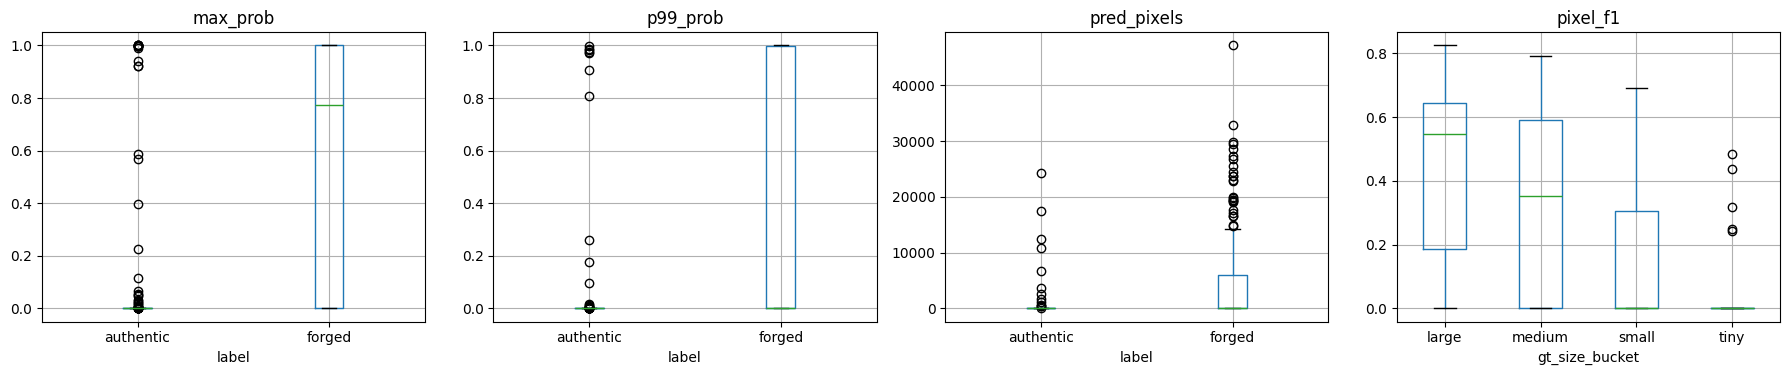

In [39]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
diagnostic_df.boxplot(column="max_prob", by="label", ax=axes[0])
diagnostic_df.boxplot(column="p99_prob", by="label", ax=axes[1])
diagnostic_df.boxplot(column="pred_pixels", by="label", ax=axes[2])
diagnostic_df.query("label == 'forged'").boxplot(column="pixel_f1", by="gt_size_bucket", ax=axes[3])
for ax in axes:
    ax.set_title(ax.get_title().replace(" by label", ""))
fig.suptitle("")
fig.tight_layout()


## Plot Examples

Authentic false positives


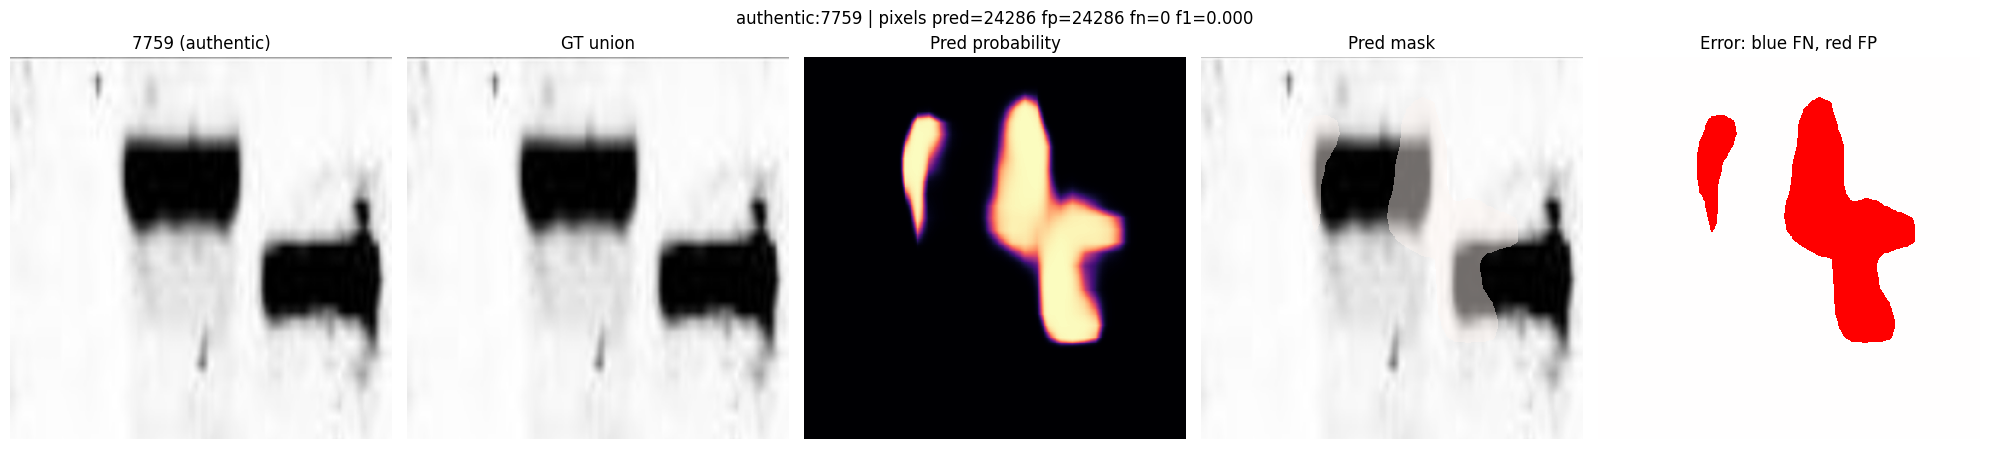

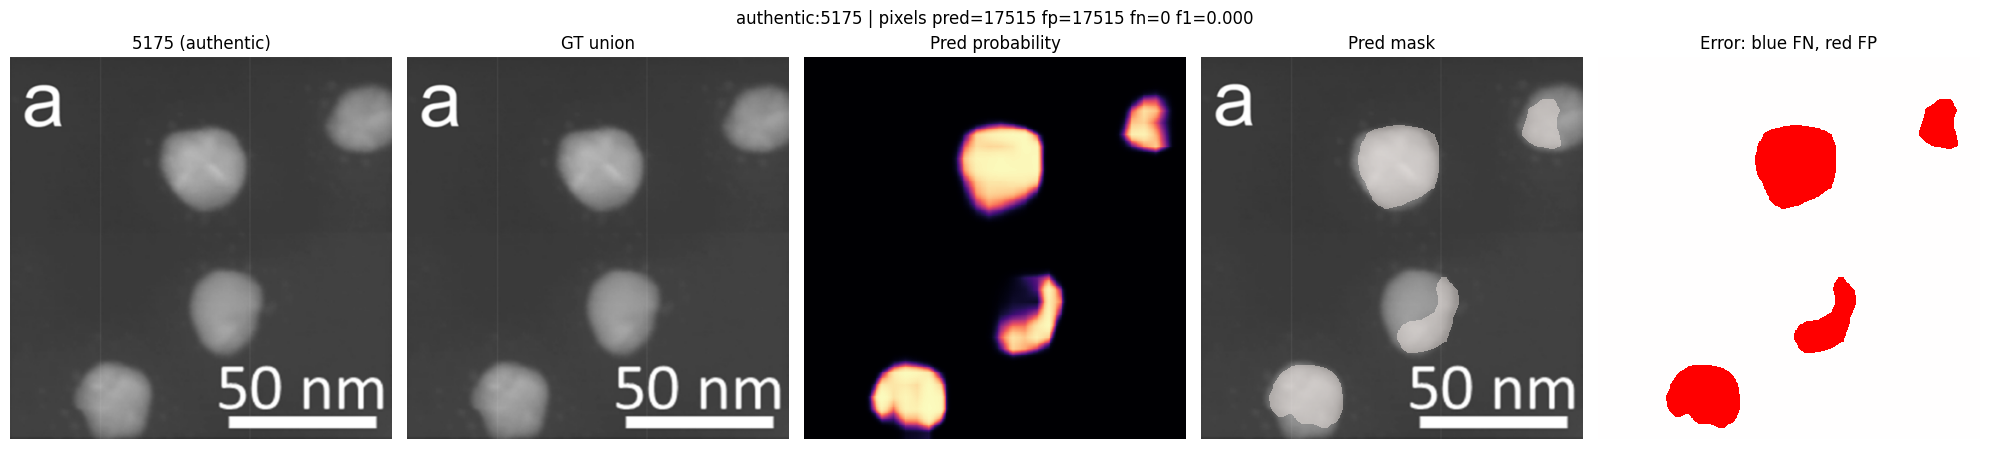

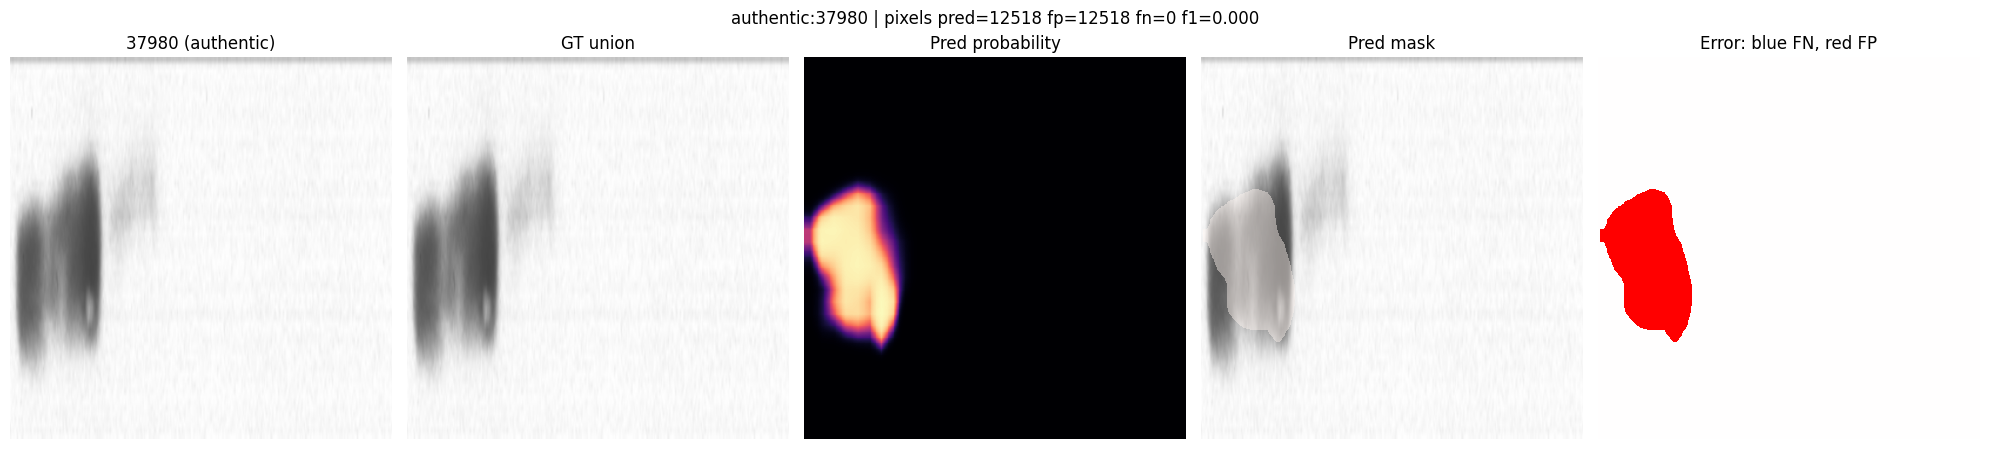

Forged misses


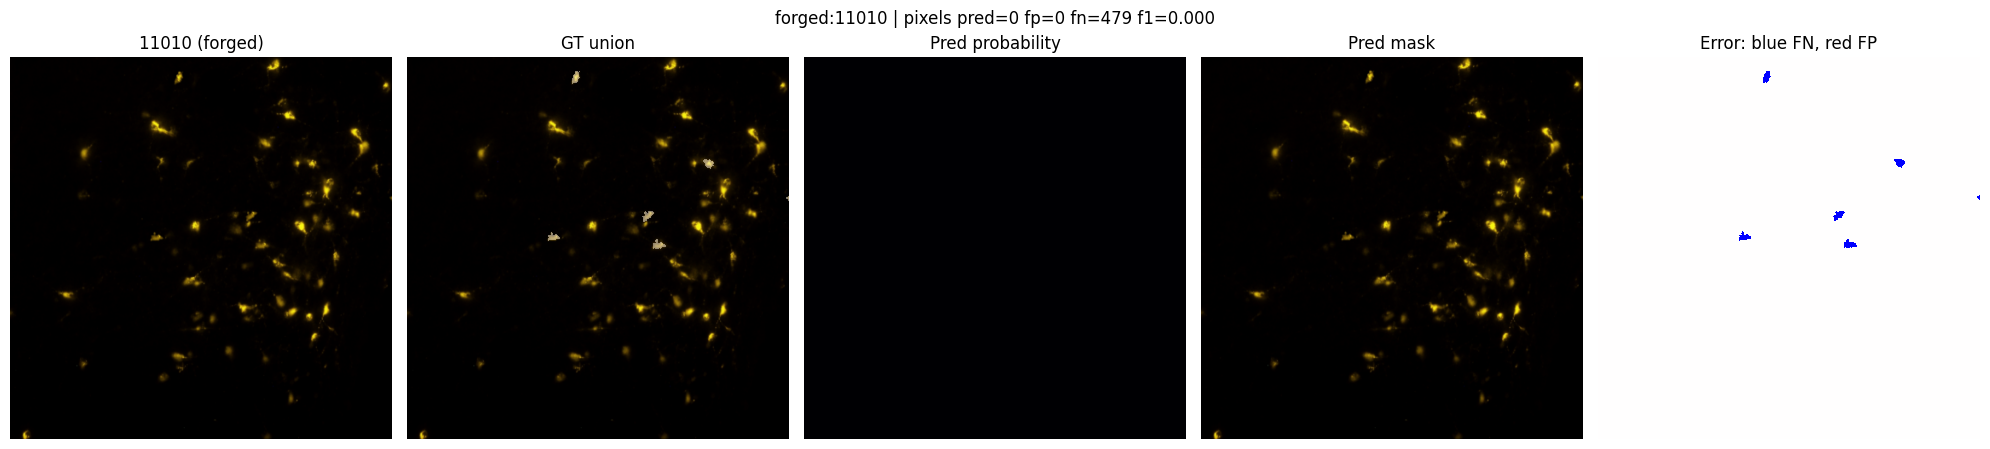

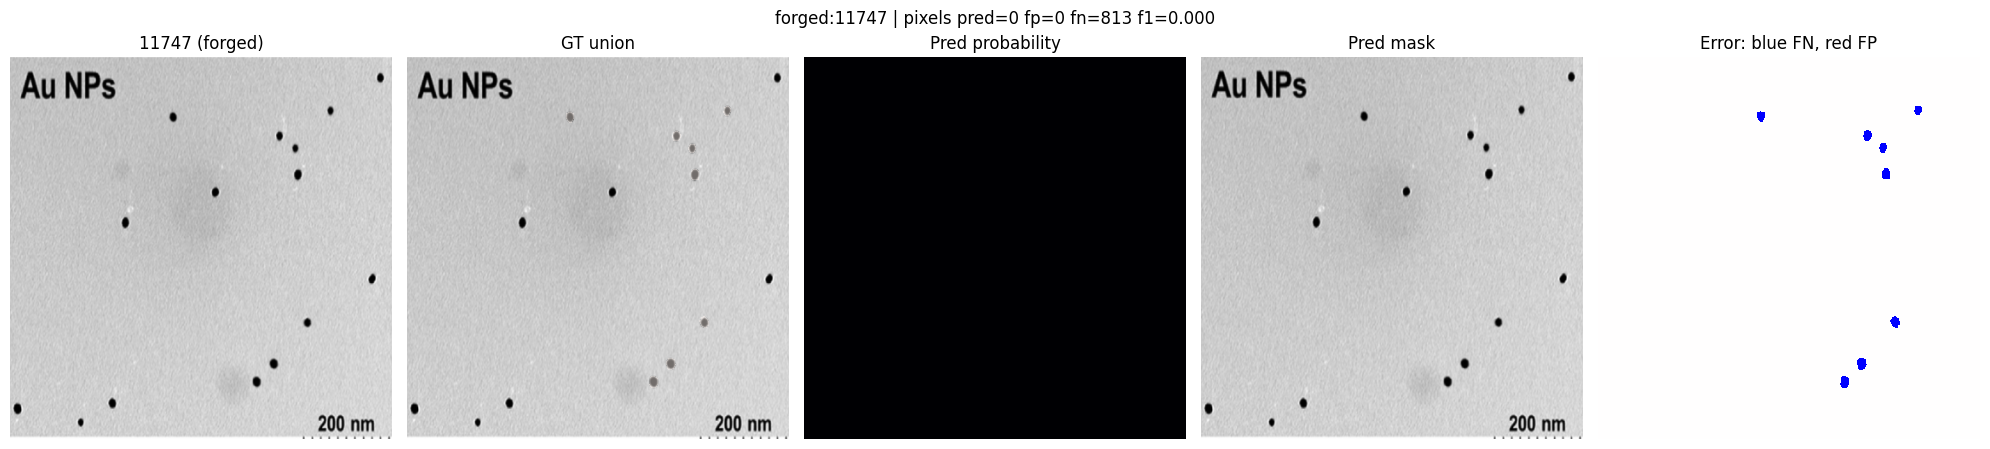

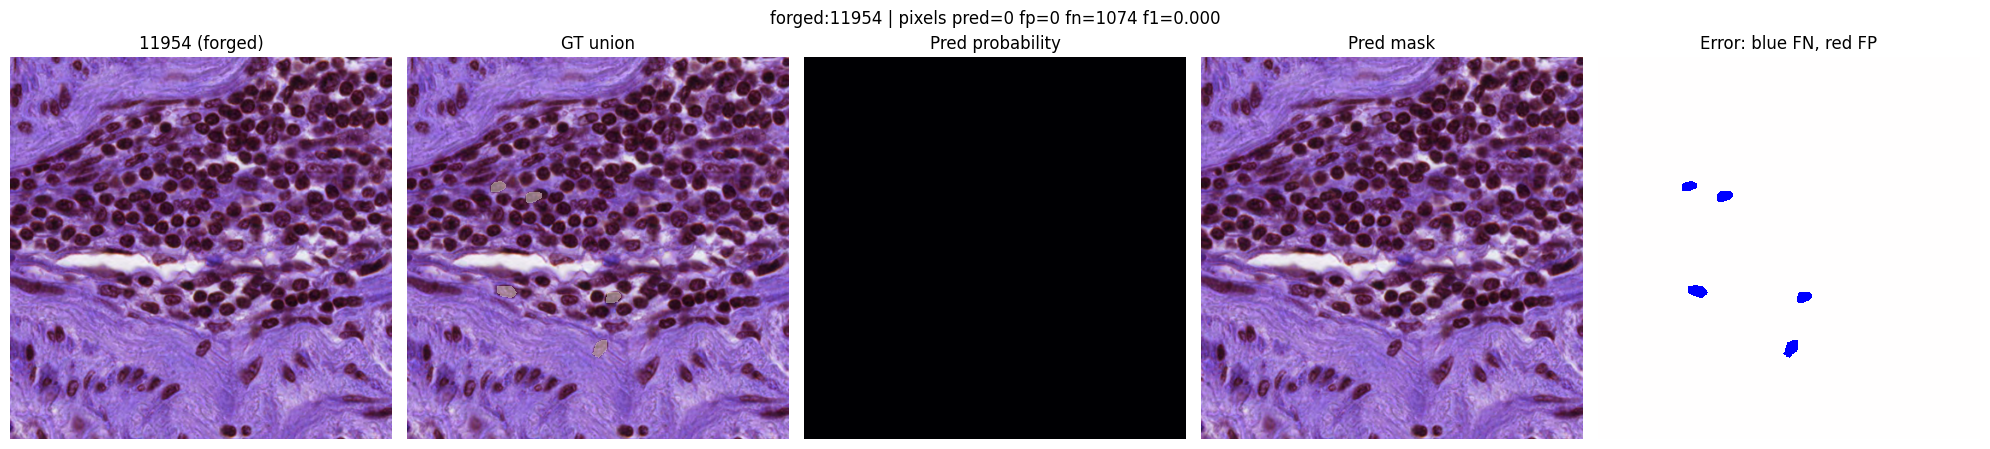

Forged successes


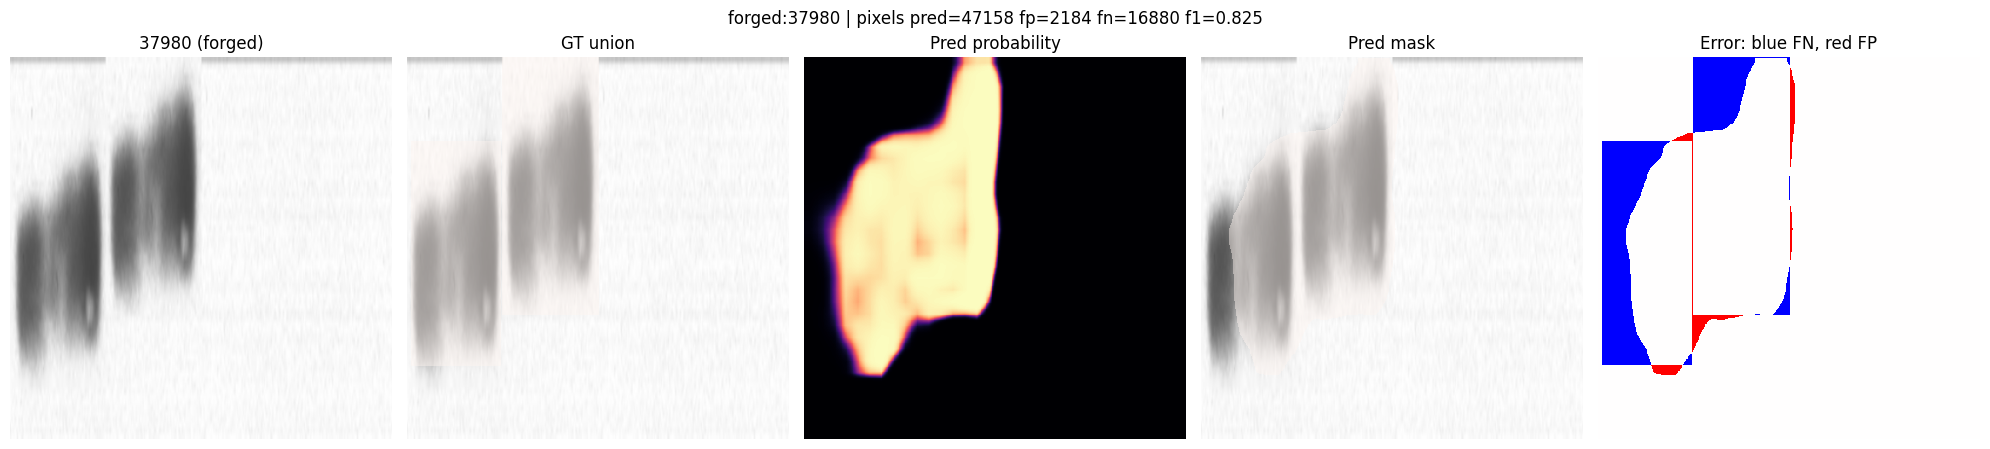

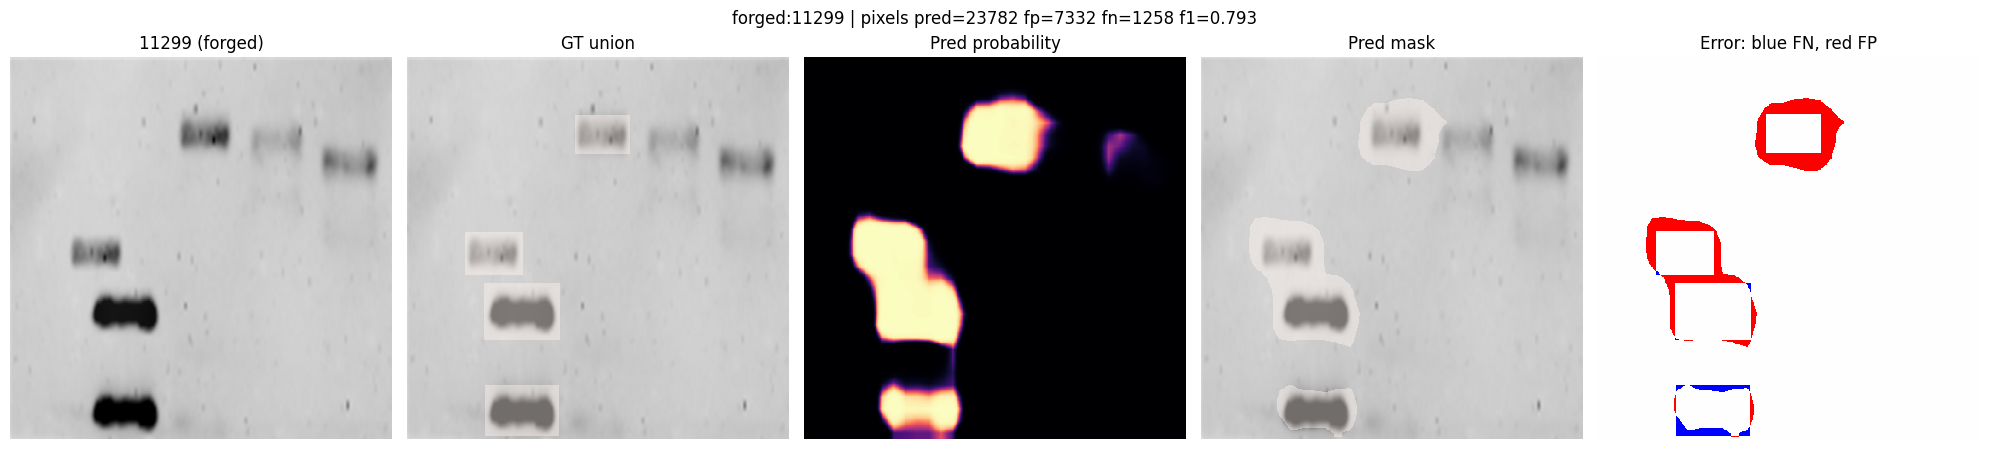

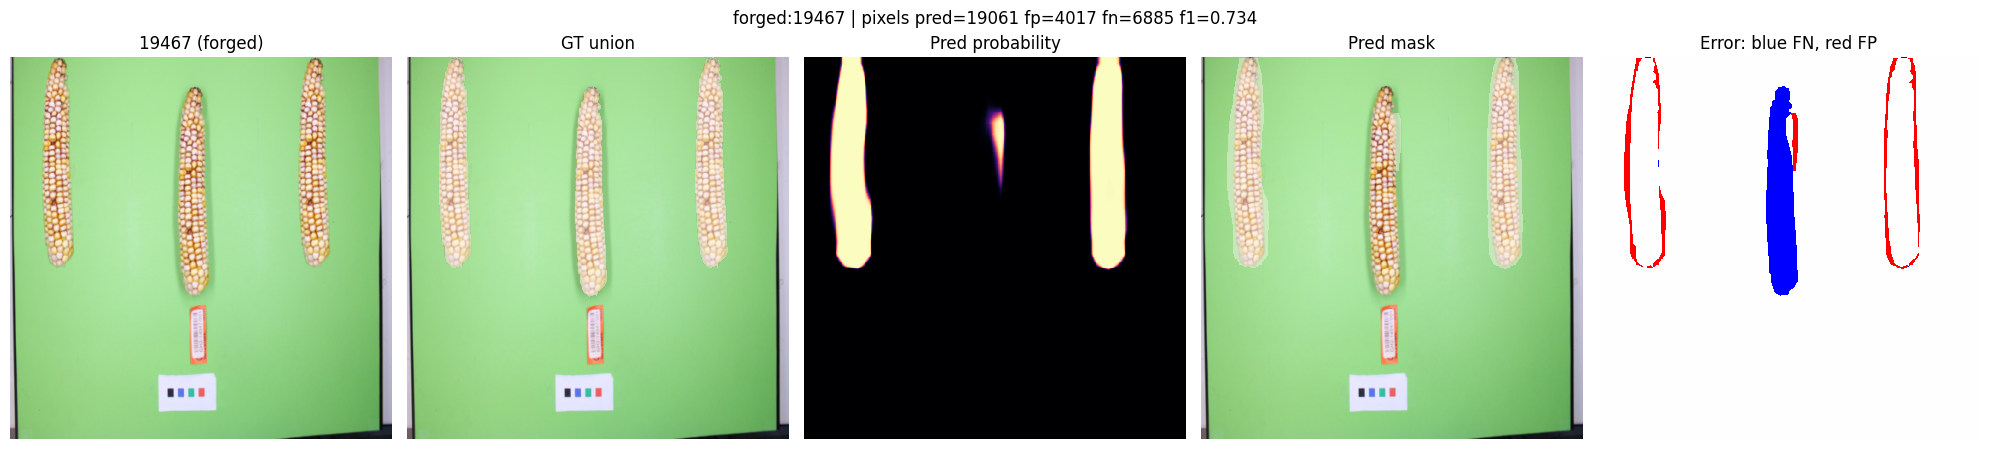

Authentic clean examples


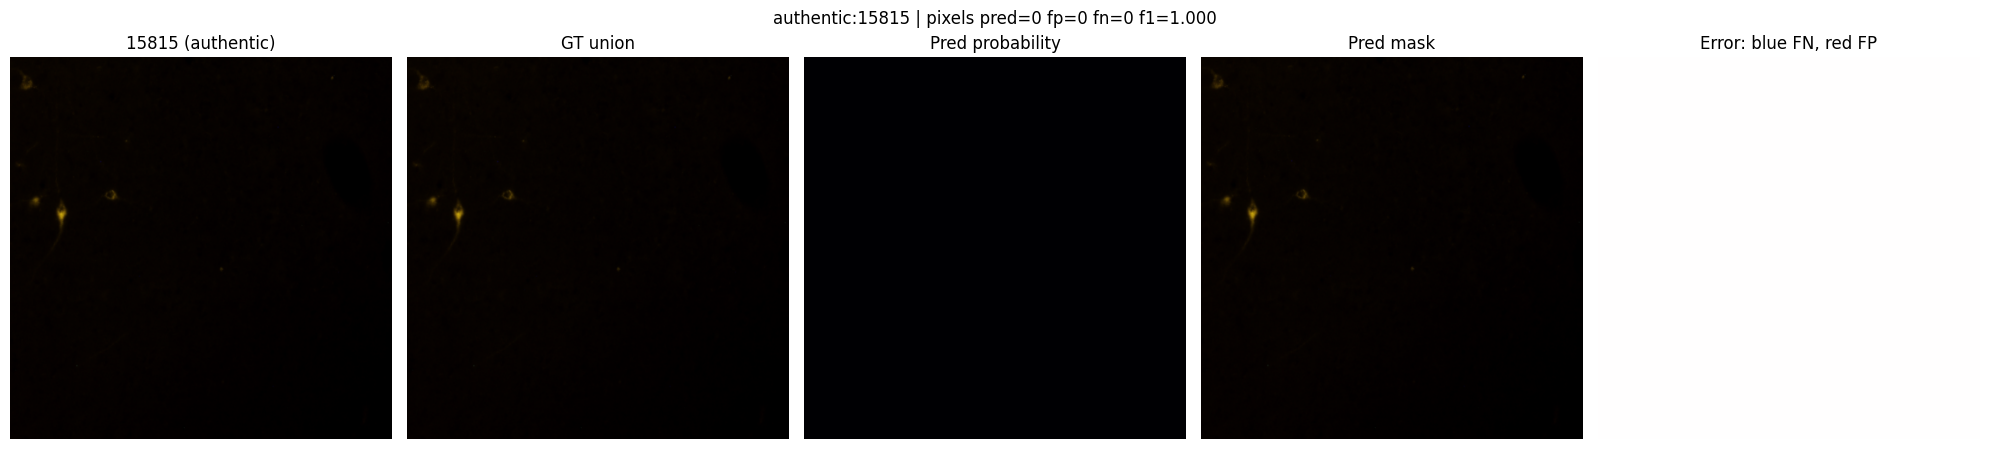

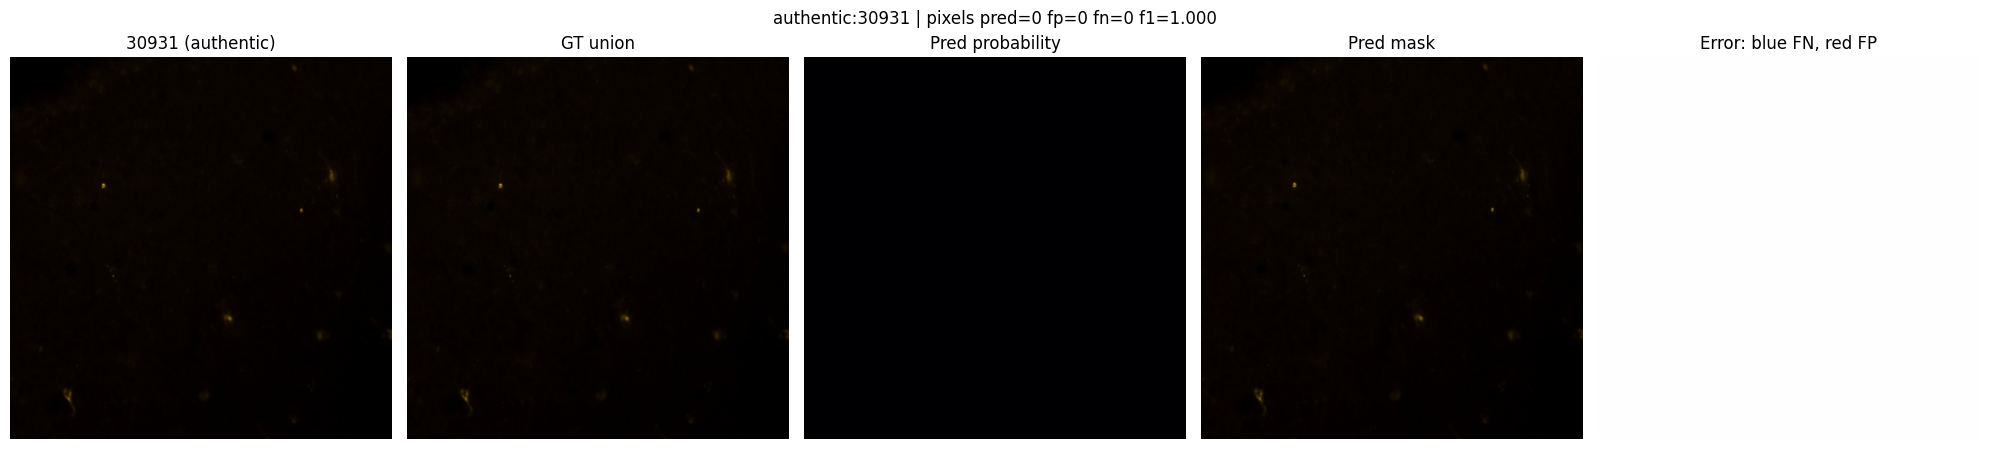

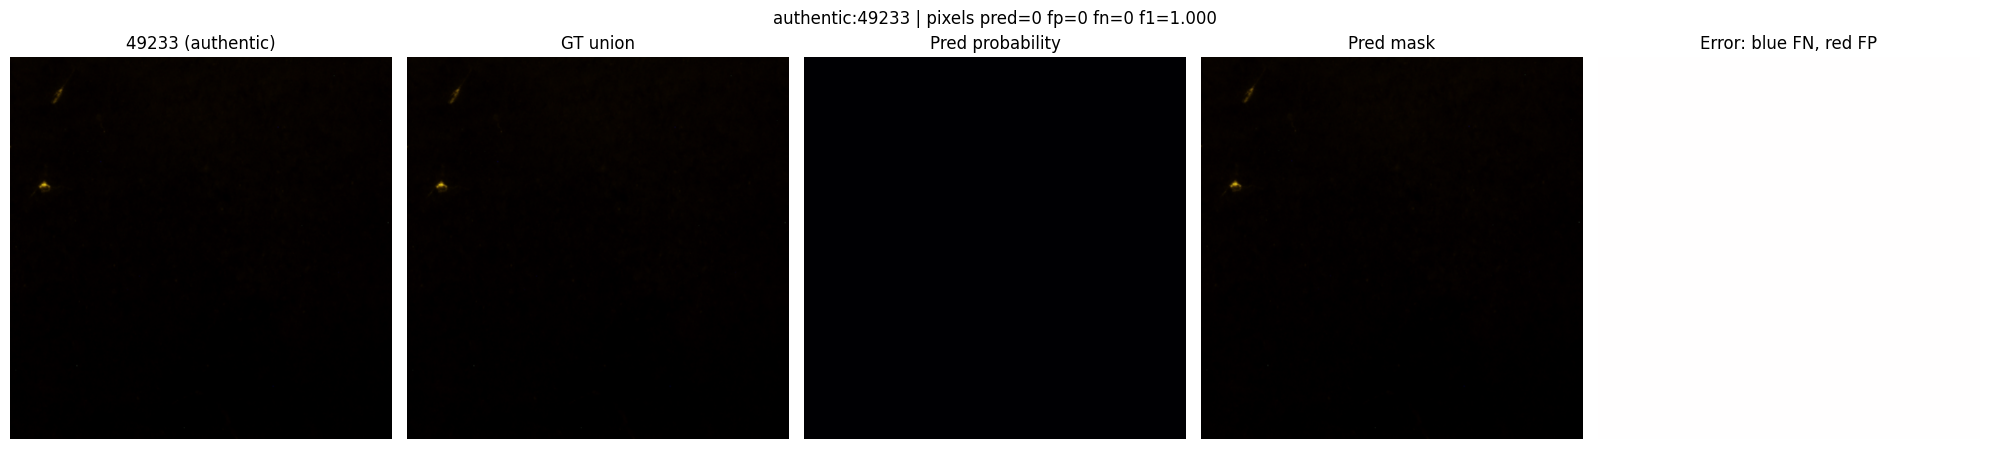

Random validation examples


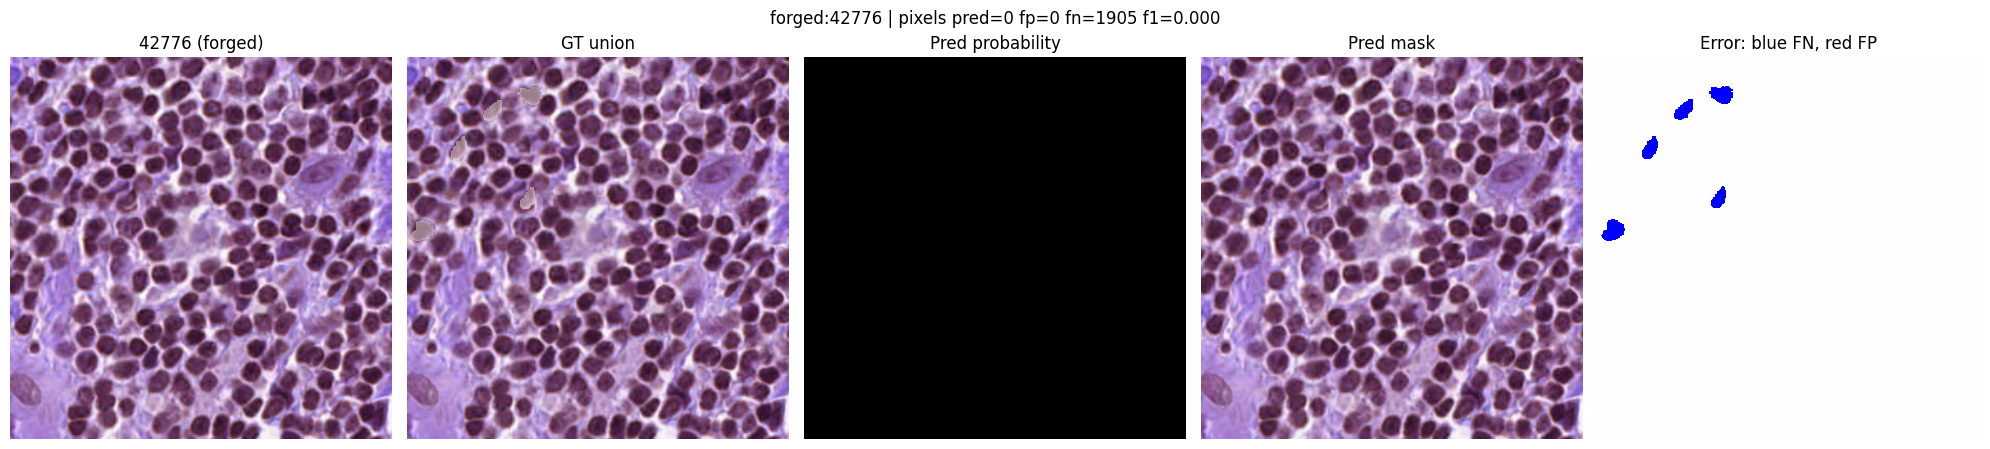

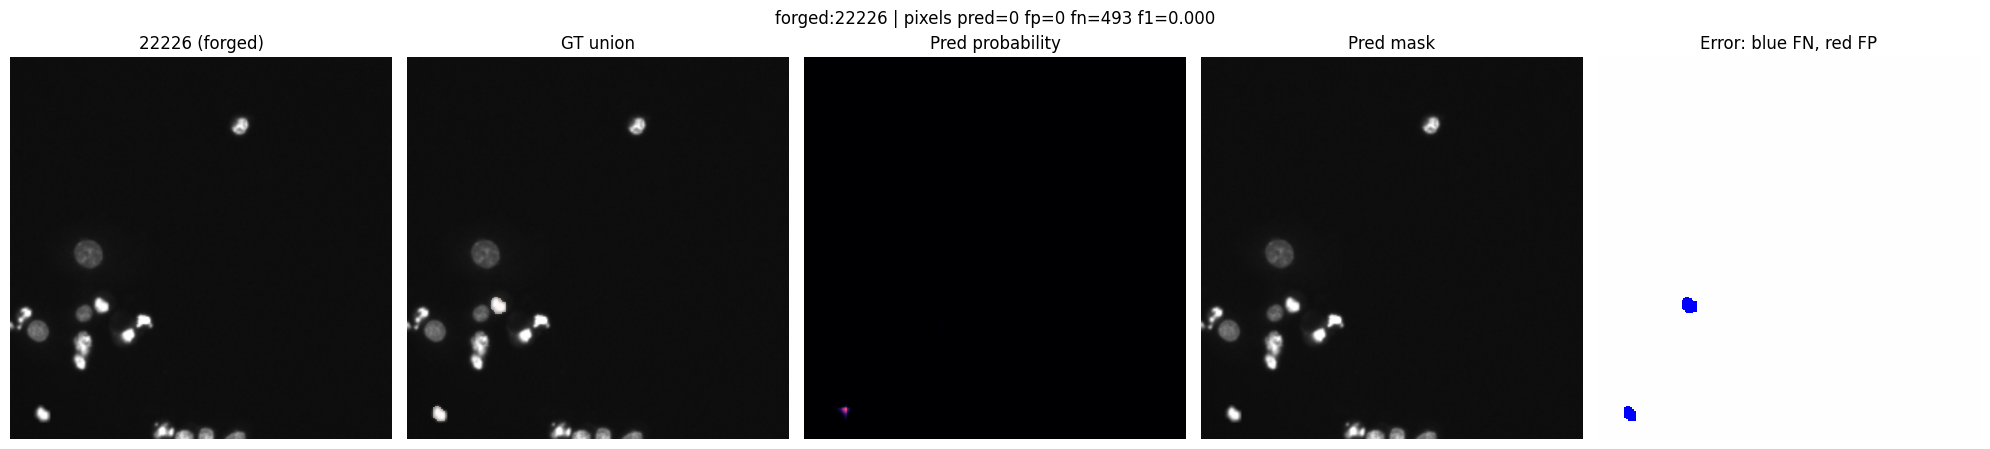

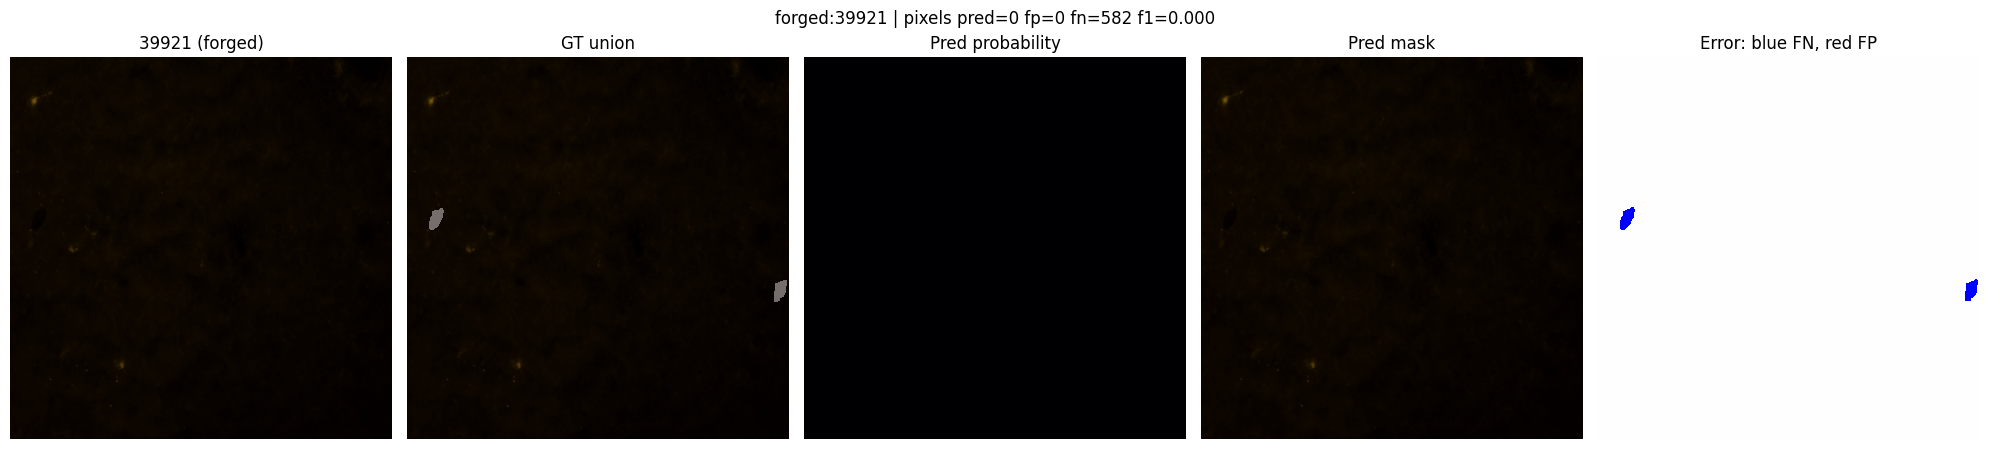

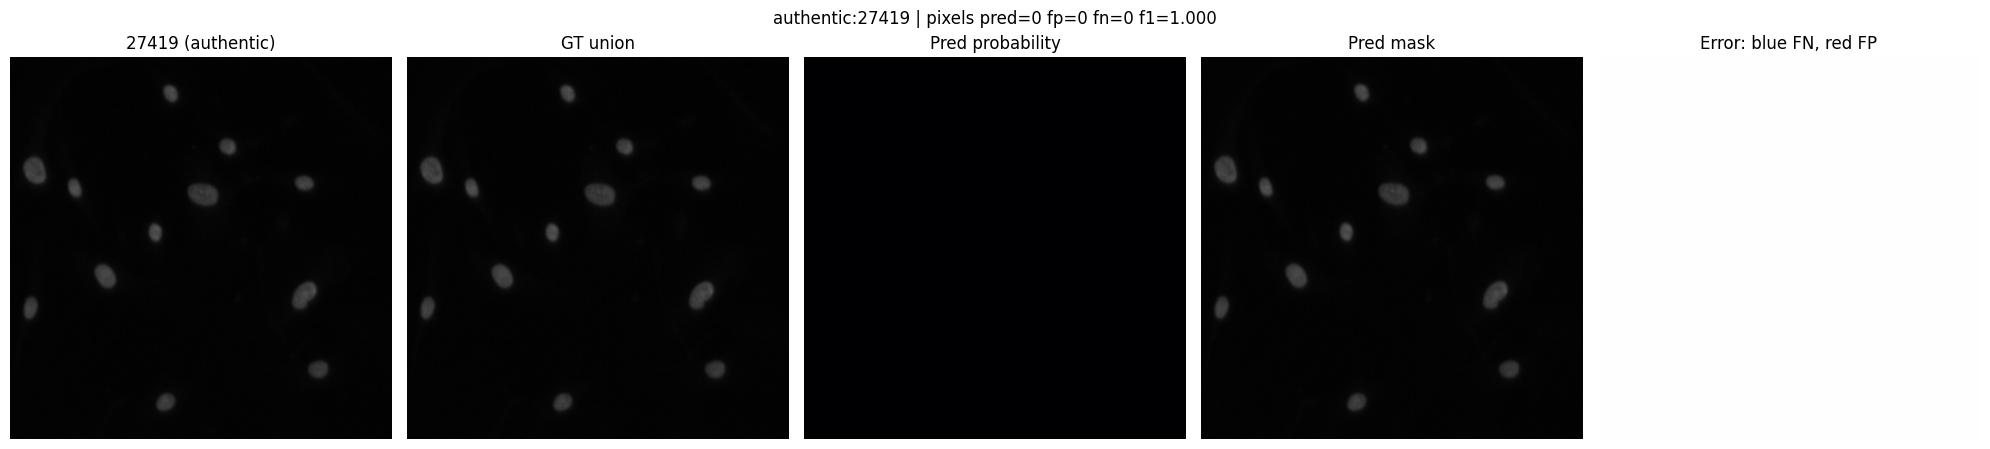

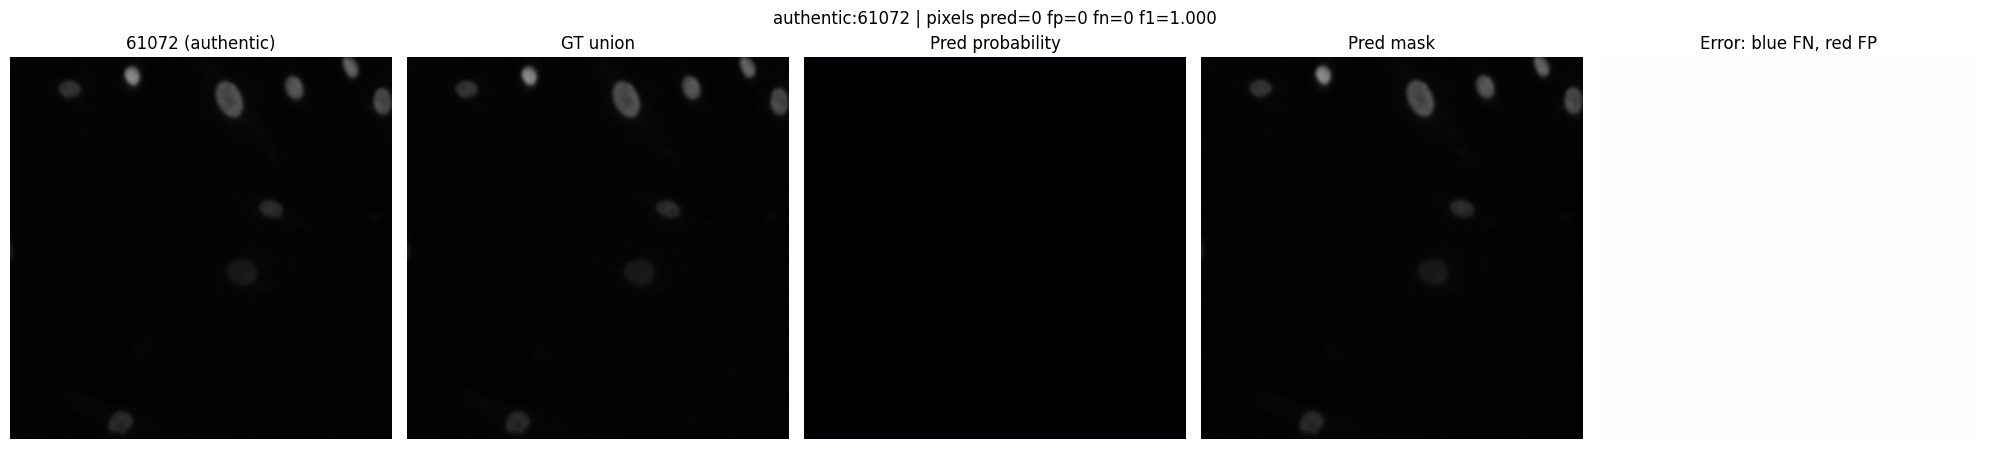

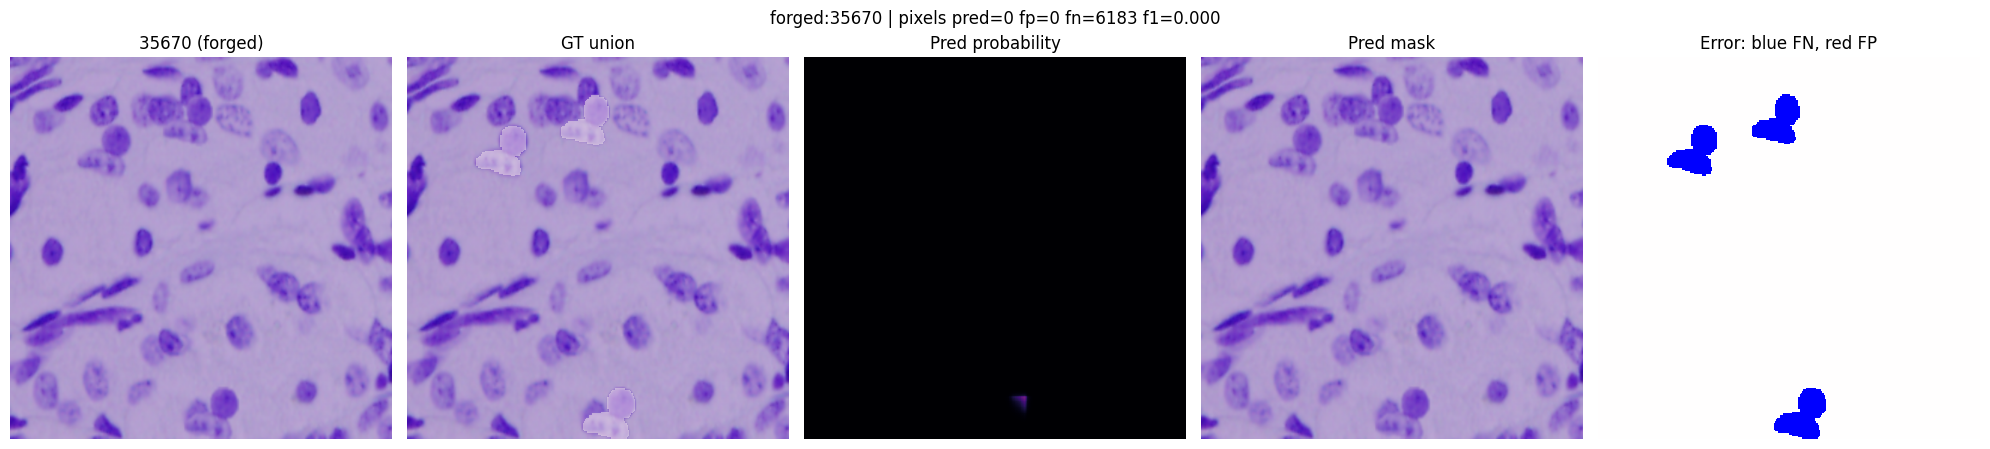

In [40]:
plotter = ForgeryDataPlotter(config.data_root)


def plot_rows(df, n=3, title=""):
    print(title)
    if len(df) == 0:
        print("No rows to plot.")
        return
    for _, row in df.head(n).iterrows():
        prediction = predictions[int(row.idx)]
        pred_bin = pred_mask_for_prediction(prediction, threshold=threshold)
        fig, axes = plotter.plot_prediction(prediction.sample, prediction.probability, pred_mask=pred_bin, threshold=threshold)
        fig.suptitle(
            f"{row.sample_id} | pixels pred={row.pred_pixels} fp={row.fp_pixels} fn={row.fn_pixels} f1={row.pixel_f1:.3f}",
            y=1.03,
        )
        plt.show()

forged_successes = diagnostic_df.query("label == 'forged' and pred_pixels > 0").sort_values(
    ["pixel_f1", "recall", "precision"], ascending=[False, False, False]
)
authentic_clean = diagnostic_df.query("label == 'authentic'").sort_values(
    ["pred_pixels", "max_prob"], ascending=[True, True]
)
random_examples = diagnostic_df.sample(n=min(6, len(diagnostic_df)), random_state=7)

plot_rows(authentic_fp, n=3, title="Authentic false positives")
plot_rows(forged_misses, n=3, title="Forged misses")
plot_rows(forged_successes, n=3, title="Forged successes")
plot_rows(authentic_clean, n=3, title="Authentic clean examples")
plot_rows(random_examples, n=6, title="Random validation examples")


## Save Diagnostics

In [41]:
output_dir = Path("einar_busternet/artifacts/results")
output_dir.mkdir(parents=True, exist_ok=True)
diagnostics_path = output_dir / "validation_diagnostics.csv"
summary_path = output_dir / "validation_diagnostics_summary.csv"
nonempty_summary_path = output_dir / "validation_diagnostics_forged_nonempty_summary.csv"
size_bucket_summary_path = output_dir / "validation_diagnostics_size_bucket_summary.csv"
diagnostic_df.to_csv(diagnostics_path, index=False)
summary.to_csv(summary_path, index=False)
forged_nonempty_summary.to_csv(nonempty_summary_path, index=False)
size_bucket_summary.to_csv(size_bucket_summary_path, index=False)
print(diagnostics_path)
print(summary_path)
print(nonempty_summary_path)
print(size_bucket_summary_path)


einar_busternet/artifacts/results/validation_diagnostics.csv
einar_busternet/artifacts/results/validation_diagnostics_summary.csv
einar_busternet/artifacts/results/validation_diagnostics_forged_nonempty_summary.csv
einar_busternet/artifacts/results/validation_diagnostics_size_bucket_summary.csv


## Cleanup GPU Memory

Run this when you are done inspecting predictions. Restarting the notebook kernel also frees everything.

In [42]:
import gc

for name in [
    "model",
    "wrapped_model",
    "val_loader",
    "predictions",
]:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print(f"CUDA allocated after cleanup: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"CUDA reserved after cleanup: {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
else:
    print("CUDA not available")


CUDA allocated after cleanup: 354.1 MB
CUDA reserved after cleanup: 596.0 MB
